In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
from datetime import datetime
import os
import pytz
import json
import seaborn as sns
import ast
from scipy.stats import gmean
import math
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Function Definition

In [2]:
# Covert string to list
def tolist(str):
        json_str = str.replace("'", '"')
        parsed = json.loads(json_str)
        return [[float(x) for x in sublist] for sublist in parsed]
# Find Median of a list
def median(x):
    L=list(x)
    sort=sorted(L)
    if len(sort) % 2 != 0:
        index=int((len(sort)+1)/2-1)
        n=sort[index]
    if len(sort) % 2 == 0:
        index=int(len(sort)/2)
        index1=index-1
        n=(sort[index]+sort[index1])/2
    return n
# Weighted Median
def weightedmidian(x):
    D=[]
    number=0
    price=0
    for l in x:
        number+=l[1]
        D.append([number,l[0]])
    if number % 2 != 0:
        index=int((number+1)/2)
    if number % 2 == 0:
        index=int(number/2)
    if index<=D[0][0]:
        price+=D[0][1]
    elif index>D[0][0]:
        for n in range(1,len(D)-1):
            if index==D[n][0] or D[n-1][0]<index<D[n][0]:
                price+=D[n][1]
    return price
# Weighted Arithmetic Mean
def weightedArithmetic(x):
    total_price=0
    total_quantity=0
    for l in x:
        price=l[0]*l[1]
        total_price+=price
        total_quantity+=l[1]
    if total_quantity !=0:
        mean=total_price/total_quantity
    else:
        mean=np.nan
    return mean
# WeightedGeometric
def weightedGeometric(x):
    l1=[]
    l2=[]
    for l in x:
        l1.append(l[0])
        l2.append(l[1])
    if sum(l2)!=0:
        mean=gmean(l1,weights=l2) 
    else:
        mean=np.nan
    return mean
# Weighted Variance
def weightedstandarddeviation(x):
    data=[]
    weight=[]
    for l in x:
        data.append(l[0])
        weight.append(l[1])
    data1 = np.asarray(data)
    weights = np.asarray(weight)
    if sum(weights)!=0:
         average = np.average(data1, weights=weights)
         variance = np.average((data1-average)**2, weights=weights)
    else:
        return np.nan
    return math.sqrt(variance)

# Extract

In [3]:
## Extract
# 1. Extract Data
dfs = pd.read_csv('MarketDepthDataLisa.csv')
dfs['Time']=dfs['Time'].astype(int)

# Transform

In [4]:
## Transform
# 1.Check missing values of columns
columns_with_missing_values = dfs.columns[dfs.isna().any()]
print("Columns with missing values:", columns_with_missing_values.tolist())
# 2.Change Datatype (a. str to list b.str to float)
if dfs['BidData'].apply(lambda x: isinstance(x, list)).any()==False:
    dfs['BidData']=dfs['BidData'].apply(tolist)
if dfs['AskData'].apply(lambda x: isinstance(x, list)).any()==False:
    dfs['AskData']=dfs['AskData'].apply(tolist)
# 3.Add columns(features) Add features that reflects volatility and returns paper(https://www.sciencedirect.com/science/article/pii/S1544612321001124#sec0008)
dfs['Datetime'] = pd.to_datetime(dfs['Time'], unit='ms')
dfs['BidNumber']=dfs['BidData'].str.len()
dfs['AskNumber']=dfs['AskData'].str.len()
dfs['BestBidPrice']=dfs['BidData'].apply(lambda row: max(x[0] for x in row) if isinstance(row, list) and row and all(isinstance(sublist, list) for sublist in row) else np.nan)
dfs['BestAskPrice']=dfs['AskData'].apply(lambda row: min(x[0] for x in row) if isinstance(row, list) and row and all(isinstance(sublist, list) for sublist in row) else np.nan)
dfs['BestBidQuantity']=dfs['BidData'].apply(lambda row: next((x[1] for x in row if x[0] == max(y[0] for y in row)), np.nan) if isinstance(row, list) and row and all(isinstance(sublist, list) for sublist in row) else np.nan)
dfs['BestAskQuantity']=dfs['AskData'].apply(lambda row: next((x[1] for x in row if x[0] == max(y[0] for y in row)), np.nan) if isinstance(row, list) and row and all(isinstance(sublist, list) for sublist in row) else np.nan)
dfs['Spread']=dfs['BestAskPrice']-dfs['BestBidPrice']
dfs['MidBidPrice']=dfs['BidData'].apply(lambda row: median(x[0] for x in row) if isinstance(row, list) and row and all(isinstance(sublist, list) for sublist in row) else np.nan)
dfs['MidAskPrice']=dfs['AskData'].apply(lambda row: median(x[0] for x in row) if isinstance(row, list) and row and all(isinstance(sublist, list) for sublist in row) else np.nan)
dfs['MidAskQuantity']=dfs['AskData'].apply(lambda row: next((x[1] for x in row if x[0] == median(y[0] for y in row)), np.nan) if isinstance(row, list) and row and all(isinstance(sublist, list) for sublist in row) else np.nan)
dfs['MidBidQuantity']=dfs['BidData'].apply(lambda row: next((x[1] for x in row if x[0] == median(y[0] for y in row)), np.nan) if isinstance(row, list) and row and all(isinstance(sublist, list) for sublist in row) else np.nan)
dfs['WeightedMidBidPrice']=dfs['BidData'].apply(lambda row: weightedmidian(row) if isinstance(row, list) and row and all(isinstance(sublist, list) for sublist in row) else np.nan)
dfs['WeightedMidAskPrice']=dfs['AskData'].apply(lambda row: weightedmidian(row) if isinstance(row, list) and row and all(isinstance(sublist, list) for sublist in row) else np.nan)
dfs['TotalBidQuantity']=dfs['BidData'].apply(lambda row: sum(x[1] for x in row) if isinstance(row, list) and row and all(isinstance(sublist, list) for sublist in row) else np.nan)
dfs['TotalAskQuantity']=dfs['AskData'].apply(lambda row: sum(x[1] for x in row) if isinstance(row, list) and row and all(isinstance(sublist, list) for sublist in row) else np.nan)
dfs['WeightedAverageBidPriceArithmetic']=dfs['BidData'].apply(lambda row: weightedArithmetic(row) if isinstance(row, list) and row and all(isinstance(sublist, list) for sublist in row) else np.nan)
dfs['WeightedAverageAskPriceArithmetic']=dfs['AskData'].apply(lambda row: weightedArithmetic(row) if isinstance(row, list) and row and all(isinstance(sublist, list) for sublist in row) else np.nan)
dfs['GeometricMeanBidPrice']=dfs['BidData'].apply(lambda row: weightedGeometric(row) if isinstance(row, list) and row and all(isinstance(sublist, list) for sublist in row) else np.nan)
dfs['GeometricMeanAskPrice']=dfs['AskData'].apply(lambda row: weightedGeometric(row) if isinstance(row, list) and row and all(isinstance(sublist, list) for sublist in row) else np.nan)
dfs['STDBid']=dfs['BidData'].apply(lambda row: weightedstandarddeviation(row) if isinstance(row, list) and row and all(isinstance(sublist, list) for sublist in row) else np.nan)
dfs['STDAsk']=dfs['AskData'].apply(lambda row: weightedstandarddeviation(row) if isinstance(row, list) and row and all(isinstance(sublist, list) for sublist in row) else np.nan)
dfs['volatility'] = dfs['Spread'].rolling(window=3).std()
dfs['volatility'] = dfs['volatility'].fillna(dfs['volatility'].mean())
# 4.Group Data
grouped=dfs.groupby('Symbol')
Data={}
BidData={}
AskData={}
for df1 in grouped:
    Symbol=df1[0]
    df=df1[1]
    #df=torch.tensor(df.values, dtype=torch.float32)
    df.set_index('Datetime', inplace=True)
    df['time_interval'] = df.index.to_series().diff().dt.total_seconds()
    df['time_interval']=df['time_interval'].fillna(0)
    Data[Symbol]=df
    #dfs.set_index('Datetime', inplace=True)
    #dfs['time_interval'] = df.index.to_series().diff().dt.total_seconds().fillna(0)
# 5.Delete Duplicates
    firstID=df['FirstID'].values
    finalID=df['FinalID'].values
    # FirstID of the previous row must > FinalID of the next row
    num=len(firstID)-2
    diff=[]
    for i in range(0,num):
        difference=firstID[i+1]-finalID[i]
        initial_columns = df.shape[1]
        if difference<=0: #Drop rows in this condition
            diff.append(difference)
            dropdata=df.drop(i+1)
            final_columns = dropdata.shape[1]
            print(initial_columns-final_columns )
    if len(diff)==0:
        print('No Duplicates')  

Columns with missing values: []
No Duplicates
No Duplicates
No Duplicates
No Duplicates
No Duplicates
No Duplicates
No Duplicates


# Load

In [5]:
#!pip install scikit-learn
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
feature1=['BestBidPrice', 'BestAskPrice',
       'BestBidQuantity', 'BestAskQuantity', 'Spread', 'MidBidPrice',
       'MidAskPrice', 'MidAskQuantity', 'MidBidQuantity',
       'WeightedMidBidPrice', 'WeightedMidAskPrice', 'TotalBidQuantity',
       'TotalAskQuantity', 'WeightedAverageBidPriceArithmetic',
       'WeightedAverageAskPriceArithmetic', 'GeometricMeanBidPrice',
       'GeometricMeanAskPrice', 'STDBid', 'STDAsk']
features=['BidNumber', 'AskNumber', 'BestBidPrice', 'BestAskPrice',
       'BestBidQuantity', 'BestAskQuantity', 'Spread', 'MidBidPrice',
       'MidAskPrice', 'MidAskQuantity', 'MidBidQuantity',
       'WeightedMidBidPrice', 'WeightedMidAskPrice', 'TotalBidQuantity',
       'TotalAskQuantity', 'WeightedAverageBidPriceArithmetic',
       'WeightedAverageAskPriceArithmetic', 'GeometricMeanBidPrice',
       'GeometricMeanAskPrice', 'STDBid', 'STDAsk', 'time_interval']
FeatureData={}
# Data Partition
for key,item in Data.items():
    for i in feature1:
        item[i].fillna(item[i].mean(), inplace=True)
    Xdf = item[features].copy()
    for col in features:
        if col=='MidBidPrice' or col=='MidAskPrice':
            Xdf[col]=MinMaxScaler().fit_transform(item[[col]])
        else:
            Xdf[col]= StandardScaler().fit_transform(item[[col]])
        FeatureData[key]=Xdf

In [10]:
X=FeatureData['BTCUSDT'].values
DataA=[] 
DataB=[]
for i in range (0,len(X)-8):
    a=X[i:i+8]
    b=X[i+8]
    DataA.append(a)
    DataB.append(b)
DataA=np.array(DataA)
DataB=np.array(DataB)
X_t = torch.tensor(DataA, dtype=torch.float32)
y_t = torch.tensor(DataB, dtype=torch.float32).unsqueeze(1)
print(len(DataB))

38549


In [11]:
# Spill over BTC ETH
tr_idx = int(0.5 * len(X_t))
va_idx = int(0.8 * len(y_t))
trainX, valX, testX = X_t[:tr_idx], X_t[tr_idx:va_idx], X_t[va_idx:]
trainY, valY, testY = y_t[:tr_idx], y_t[tr_idx:va_idx], y_t[va_idx:]
print(f"Train: {len(trainX)}, Val: {len(valX)}, Test: {len(testX)}")
print(trainX.size())
print(trainY.size())

Train: 19274, Val: 11565, Test: 7710
torch.Size([19274, 8, 22])
torch.Size([19274, 1, 22])


In [15]:
class LSTMModel(nn.Module):
    def __init__(self, input_dim,output_dim, hidden_dim=20, layer_dim=3):
        super(LSTMModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.layer_dim = layer_dim
        self.lstm = nn.LSTM(input_dim, hidden_dim, layer_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)  # output_dim should be 22

    def forward(self, x, h0=None, c0=None):
        if h0 is None or c0 is None:
            h0 = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim).to(x.device)
            c0 = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim).to(x.device)
        out, (hn, cn) = self.lstm(x, (h0, c0))  # out: [batch_size, seq_len, hidden_dim]
        out = self.fc(out[:, -1, :])  # [batch_size, output_dim]
        return out, hn, cn

In [16]:
model=LSTMModel(len(features),22).to(device)
criterion = nn.HuberLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=8e-4, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=7)
sequence=12

In [17]:
from torch.utils.data import DataLoader, TensorDataset
batch_size = 256
train_loader = DataLoader(TensorDataset(trainX, trainY), batch_size=batch_size, shuffle=True, pin_memory=True)
val_loader   = DataLoader(TensorDataset(valX, valY), batch_size=batch_size, shuffle=False, pin_memory=True)

In [18]:
# Train
from torch.cuda.amp import GradScaler
from torch.amp import autocast
scaler_amp = GradScaler()
epochs, es_patience, best_val = 200, 15, float('inf')
train_losses, val_losses = [], []
for epoch in range(1, epochs + 1):
    model.train()
    train_loss = 0.0
    train_samples = 0
    for bx, by in train_loader:
        bx, by = bx.to(device), by.to(device)
        optimizer.zero_grad()  # Move zero_grad before autocast
        with autocast(device_type='cuda' if device.type == 'cuda' else 'cpu'):
            pred,_,_ = model(bx)
            loss = criterion(pred, by.squeeze(1))
        scaler_amp.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Clip before step
        scaler_amp.step(optimizer)
        scaler_amp.update()
        train_loss += loss.item() * bx.size(0)
        train_samples += bx.size(0)  
    train_loss /= train_samples  # Normalize by actual samples
    train_losses.append(train_loss)
    model.eval()
    val_loss = 0.0
    val_samples = 0
    with torch.no_grad():
        for bx, by in val_loader:
            bx, by = bx.to(device), by.to(device)
            with autocast(device_type='cuda' if device.type == 'cuda' else 'cpu'):
                pred,_,_ = model(bx)
                val_loss += criterion(pred, by.squeeze(1)).item() * bx.size(0)
            val_samples += bx.size(0)
    
    val_loss /= val_samples  # Normalize by actual samples
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    # Print progress every 10 epochs
    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

    # Early stopping and checkpointing
    if val_loss < best_val:
        best_val = val_loss
        es = 0
        # Save checkpoint with model and optimizer state
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
        }, 'spillover.pth')
    else:
        es += 1
        if es >= es_patience:
            print(f"Early stopping at epoch {epoch}")
            break


/opt/anaconda3/envs/d2l/lib/python3.9/site-packages/torch/cuda/amp/grad_scaler.py:120: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn("torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.")


Epoch  10 | Train Loss: 0.108121 | Val Loss: 0.109905
Epoch  20 | Train Loss: 0.107412 | Val Loss: 0.108756
Epoch  30 | Train Loss: 0.106947 | Val Loss: 0.108072
Epoch  40 | Train Loss: 0.106383 | Val Loss: 0.108107
Epoch  50 | Train Loss: 0.103207 | Val Loss: 0.105145
Epoch  60 | Train Loss: 0.101912 | Val Loss: 0.103839
Epoch  70 | Train Loss: 0.101455 | Val Loss: 0.103964
Epoch  80 | Train Loss: 0.101254 | Val Loss: 0.103874
Epoch  90 | Train Loss: 0.101173 | Val Loss: 0.103905
Early stopping at epoch 96


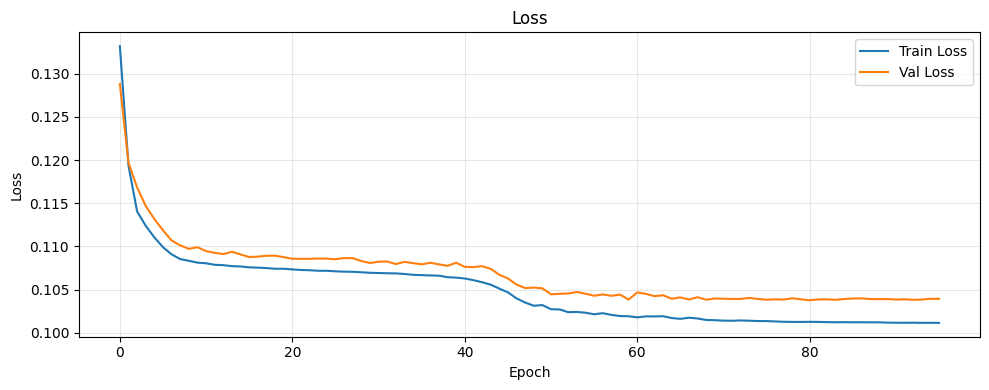

In [19]:
# Loss plot
plt.figure(figsize=(10,4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout();  plt.show()

# Data Discovery

In [ ]:
# 1.Outlier Data
    # a. Store Price Data for each coin in dictionary
    BidData[Symbol]=[]
    AskData[Symbol]=[]
    i=0
    for d in df['BidData']:
        for i in d:
            BidData[Symbol][0].append(i[0])
            BidData[Symbol][1].append(i[1]) 
        i+=1
    for d in df['AskData']:
        for i in d:
            AskData[Symbol][0].append(i[0])
            AskData[Symbol][1].append(i[1])
cleanedBidData={}
cleanedAskData={}
bidnum=0
asknum
for key,value in BidData.items():
    q1_bid = np.percentile(value, 25)
    q3_bid = np.percentile(value, 75)
    iqr = q3_bid - q1_bid
    lower_bound_bid = q1_bid - (1.5 * iqr)
    upper_bound_bid = q3_bid + (1.5 * iqr)
for key,value in AskData.items():
    q1_ask = np.percentile(value, 25)
    q3_ask = np.percentile(value, 75)
    iqr = q3_ask - q1_ask
    lower_bound_ask = q1_ask - (1.5 * iqr)
    upper_bound_ask = q3_ask + (1.5 * iqr)